# 🎓 Final Assignment for Machine Learning
### **Topic:** Comparative Study of Machine Learning Models for Cardiovascular Disease (CVD) Prediction

---

| **Academic Details** | **Information** |
| :--- | :--- |
| **Instructor** | Prof. Mamta Bhattarai Lamsal |
| **Submitted by** | **Yalamber Ingnam** |
| **Institution** | Madan Bhandari University of Science and Technology (MBUST), Chitlang, Nepal |
| **Course** | Machine Learning |
| **Date** | September 2026 |

---


## 📑 Table of Contents

1. [Introduction & Problem Formulation](#1-introduction--problem-formulation)
2. [Dataset Description & Clinical Feature Glossary](#2-dataset-description--clinical-feature-glossary)
3. [Environment Setup & Library Ingestion](#3-environment-setup--library-ingestion)
4. [Data Loading & Exploratory Data Analysis (EDA)](#4-data-loading--exploratory-data-analysis-eda)
5. [Data Preprocessing & Feature Engineering](#5-data-preprocessing--feature-engineering)
6. [Machine Learning Algorithms Benchmarked](#6-machine-learning-algorithms-benchmarked)
7. [Model Training & Hyperparameter Optimization](#7-model-training--hyperparameter-optimization)
8. [Comparative Performance Evaluation & Visualizations](#8-comparative-performance-evaluation--visualizations)
9. [Feature Importance & Model Interpretability](#9-feature-importance--model-interpretability)
10. [Discussion, Clinical Trade-offs & Conclusion](#10-discussion-clinical-trade-offs--conclusion)
11. [References](#11-references)

---

## 1. Introduction & Problem Formulation

### 1.1 Clinical Background
Cardiovascular diseases (CVDs) remain the leading cause of mortality globally, taking an estimated 17.9 million lives each year according to the World Health Organization (WHO). Early, non-invasive detection of CVD risk empowers clinicians to make timely medical interventions, significantly reducing mortality rates.

### 1.2 Research Objectives
The primary goal of this study is to perform a rigorous comparative assessment of multiple supervised machine learning classification algorithms for predicting the likelyhood of cardiovascular disease within 10-year based on clinical and biometric parameters.

Specifically, we aim to:
- Benchmark different classical ML 
- Mitigate data leakage and address class imbalance using robust preprocessing and stratified cross-validation.
- Evaluate models across clinical performance metrics (Accuracy, Precision, Recall/Sensitivity, F1-Score, and ROC-AUC).
- Determine key predictive biomarkers driving CVD risk through model interpretability techniques.

---

## 2. Dataset Description & Clinical Feature Glossary

| Feature | Type | Description | Clinical Context / Units |
| :--- | :--- | :--- | :--- |
| `male` | Binary | Biological sex of the patient | 1 = Male; 0 = Female |
| `age` | Numerical | Age of the patient at baseline | Years (Range: 32–70) |
| `education` | Categorical | Highest educational level attained | 1: Some High School, 2: High School/GED, 3: Some College/Vocational, 4: College Degree |
| `currentSmoker` | Binary | Current smoking status | 1 = Yes; 0 = No |
| `cigsPerDay` | Numerical | Average number of cigarettes smoked per day | Cigarettes/day (Range: 0–70) |
| `BPMeds` | Binary | Anti-hypertensive blood pressure medication | 1 = Currently on BP Meds; 0 = Not on BP Meds |
| `prevalentStroke` | Binary | History of prior cerebrovascular accident (stroke) | 1 = History of Stroke; 0 = No Stroke History |
| `prevalentHyp` | Binary | Pre-existing clinical diagnosis of hypertension | 1 = Hypertensive; 0 = Normotensive |
| `diabetes` | Binary | Clinical diagnosis of diabetes mellitus | 1 = Diabetic; 0 = Non-diabetic |
| `totChol` | Numerical | Total serum cholesterol level | mg/dL (Desirable: < 200 mg/dL) |
| `sysBP` | Numerical | Systolic blood pressure | mm Hg at baseline examination (Normal: < 120 mm Hg) |
| `diaBP` | Numerical | Diastolic blood pressure | mm Hg at baseline examination (Normal: < 80 mm Hg) |
| `BMI` | Numerical | Body Mass Index | kg/m² (Weight in kg / Height in m²) |
| `heartRate` | Numerical | Resting pulse / heart rate | Beats per minute (bpm, Normal: 60–100 bpm) |
| `glucose` | Numerical | Fasting blood glucose concentration | mg/dL (Normal fasting: 70–99 mg/dL) |
| `TenYearCHD` | Binary Target | 10-year risk of developing Coronary Heart Disease | **1 = CHD Incident; 0 = No CHD** |


# 3. Environment setup 

In [108]:
# Core scientific computing and data manipulation
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Classifiers
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, average_precision_score, precision_score, recall_score, f1_score, precision_recall_curve, auc

# Plotting configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

## 4. Data Loading & Exploratory Data Analysis (EDA)

In this section, we ingest the dataset, analyze data distributions, verify data types, check for missing values, and explore feature correlations.

In [56]:
## Reading the dataset, downloaded from the kaggle, subset of the farmingham dataset.
df = pd.read_csv("framingham.csv")
df.shape

(4238, 16)

In [57]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [59]:
df.describe().T     # ranges, means, spot impossible values

,count,mean,std,min,25%,50%,75%,max
male,4238.0,0.429212,0.495022,0.00,0.00,0.0,1.000,1.0
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.000,70.0
education,4133.0,1.978950,1.019791,1.00,1.00,2.0,3.000,4.0
currentSmoker,4238.0,0.494101,0.500024,0.00,0.00,0.0,1.000,1.0
cigsPerDay,4209.0,9.003089,11.920094,0.00,0.00,0.0,20.000,70.0
BPMeds,4185.0,0.029630,0.169584,0.00,0.00,0.0,0.000,1.0
prevalentStroke,4238.0,0.005899,0.076587,0.00,0.00,0.0,0.000,1.0
prevalentHyp,4238.0,0.310524,0.462763,0.00,0.00,0.0,1.000,1.0
diabetes,4238.0,0.025720,0.158316,0.00,0.00,0.0,0.000,1.0
totChol,4188.0,236.721585,44.590334,107.00,206.00,234.0,263.000,696.0


In [60]:
df.duplicated().sum()      # how many rows are exact copies of an earlier row/ checking for the duplicate copies

np.int64(0)

In [61]:
df.isnull().sum().sort_values(ascending=False)  # checking the missing values for any feature / column

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
age                  0
currentSmoker        0
prevalentStroke      0
prevalentHyp         0
diabetes             0
sysBP                0
diaBP                0
TenYearCHD           0
dtype: int64

In [62]:
(df.isnull().mean() * 100).round(2).sort_values(ascending=False) 


glucose            9.16
education          2.48
BPMeds             1.25
totChol            1.18
cigsPerDay         0.68
BMI                0.45
heartRate          0.02
male               0.00
age                0.00
currentSmoker      0.00
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
sysBP              0.00
diaBP              0.00
TenYearCHD         0.00
dtype: float64

In [63]:
df.isnull().any(axis=1).sum() # checking how many ROWS have gap more than 1 or equal to 1 gaps

np.int64(582)

In [64]:
df.isnull().any(axis=1).mean() * 100


np.float64(13.732892873997168)

In [65]:
(df.isnull().sum(axis=1) > 1).sum()


np.int64(61)

In [66]:
# Checking the number of unique values for each feature  
# can help us decide which to scale and which not to scale later
for col in df.columns: 
    print(f"{col:16s} {df[col].nunique():>5} unique values")

male                 2 unique values
age                 39 unique values
education            4 unique values
currentSmoker        2 unique values
cigsPerDay          33 unique values
BPMeds               2 unique values
prevalentStroke      2 unique values
prevalentHyp         2 unique values
diabetes             2 unique values
totChol            248 unique values
sysBP              234 unique values
diaBP              146 unique values
BMI               1363 unique values
heartRate           73 unique values
glucose            143 unique values
TenYearCHD           2 unique values


In [67]:
for col in df.columns:                     # go through every column, one at a time
    vals = sorted(df[col].dropna().unique().tolist())   # list its distinct values, in order
    shown = vals if len(vals) <= 6 else f"{len(vals)} different values"   # show the values if few, else just the count
    print(f"{col:16s} -> {shown}")         # print column name, padded to 16 chars, then the result

male             -> [0, 1]
age              -> 39 different values
education        -> [1.0, 2.0, 3.0, 4.0]
currentSmoker    -> [0, 1]
cigsPerDay       -> 33 different values
BPMeds           -> [0.0, 1.0]
prevalentStroke  -> [0, 1]
prevalentHyp     -> [0, 1]
diabetes         -> [0, 1]
totChol          -> 248 different values
sysBP            -> 234 different values
diaBP            -> 146 different values
BMI              -> 1363 different values
heartRate        -> 73 different values
glucose          -> 143 different values
TenYearCHD       -> [0, 1]


In [68]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

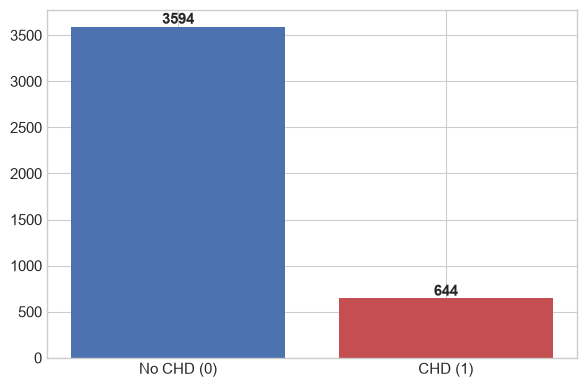

In [69]:
# 1. Counts and percentages of each class
counts = df['TenYearCHD'].value_counts().sort_index()
pct = df['TenYearCHD'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
plt.bar(['No CHD (0)', 'CHD (1)'], counts.values, color=['#4C72B0', '#C44E52'])
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=110) # saving the figure, later for the reporting

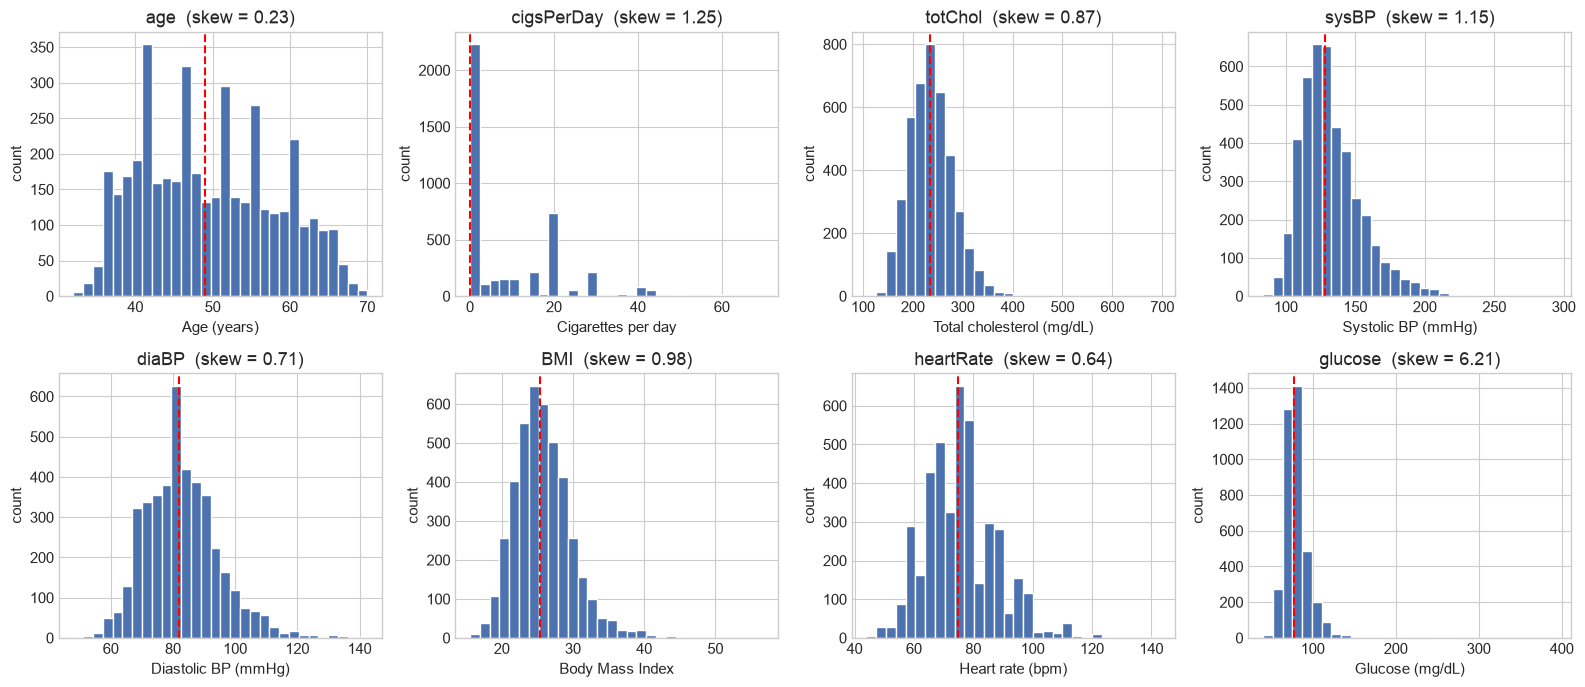

In [70]:
# Feature distribution for the continous data
continuous = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
feature_labels = {
    'age': 'Age (years)',
    'cigsPerDay': 'Cigarettes per day',
    'totChol': 'Total cholesterol (mg/dL)',
    'sysBP': 'Systolic BP (mmHg)',
    'diaBP': 'Diastolic BP (mmHg)',
    'BMI': 'Body Mass Index',
    'heartRate': 'Heart rate (bpm)',
    'glucose': 'Glucose (mg/dL)',
}
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.ravel(), continuous):
    ax.hist(df[col].dropna(), bins=30, color='#4C72B0', edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--') # checking the median for the each feature columns that are continous
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})")
    ax.set_xlabel(feature_labels[col]) 
    ax.set_ylabel('count')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=110)
plt.show()

In [71]:
df['glucose'].skew()
df.skew(numeric_only=True)

male                0.286135
age                 0.228146
education           0.690033
currentSmoker       0.023606
cigsPerDay          1.247910
BPMeds              5.550010
prevalentStroke    12.909062
prevalentHyp        0.819278
diabetes            5.994378
totChol             0.871422
sysBP               1.145362
diaBP               0.714102
BMI                 0.981974
heartRate           0.644482
glucose             6.213402
TenYearCHD          1.939741
dtype: float64

In [72]:
# checking the relationship between the risk and non-risk person
group_means = df.groupby('TenYearCHD').mean(numeric_only=True).T # grouping each numnerical row according to the target values, 0 or 1 rows values
# print(group_means)
group_means.columns = ['No CHD (0)', 'CHD (1)'] # renaming to the proper column
group_means['difference'] = group_means['CHD (1)'] - group_means['No CHD (0)']
print(group_means.round(2))

                 No CHD (0)  CHD (1)  difference
male                   0.41     0.53        0.12
age                   48.77    54.15        5.38
education              2.00     1.85       -0.15
currentSmoker          0.49     0.52        0.03
cigsPerDay             8.71    10.63        1.92
BPMeds                 0.02     0.06        0.04
prevalentStroke        0.00     0.02        0.01
prevalentHyp           0.28     0.50        0.23
diabetes               0.02     0.06        0.04
totChol              235.17   245.39       10.22
sysBP                130.33   143.62       13.29
diaBP                 82.16    86.98        4.82
BMI                   25.67    26.53        0.86
heartRate             75.76    76.53        0.77
glucose               80.68    89.01        8.33


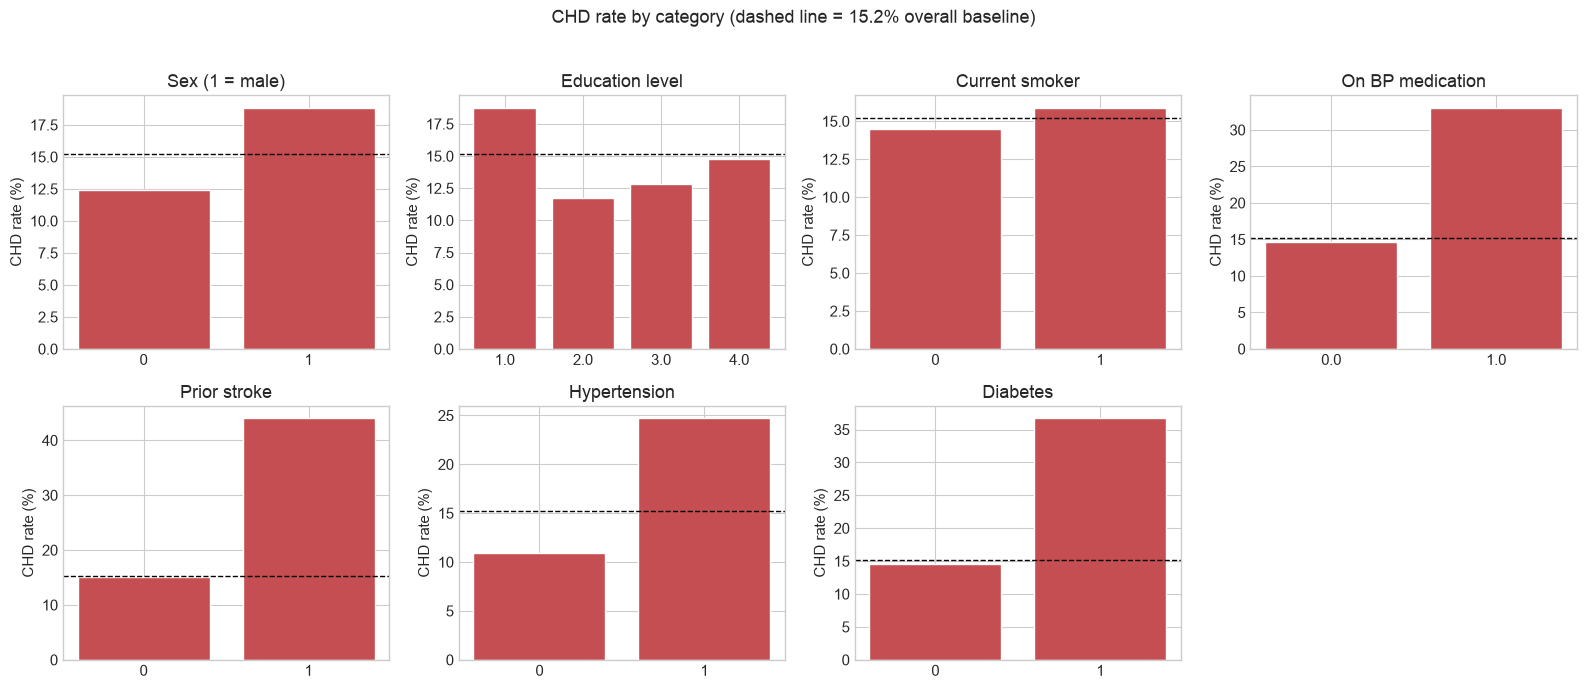

In [73]:


# 1. The categorical/binary features to plot
cols_for_bar = ["male","education","currentSmoker","BPMeds","prevalentStroke","prevalentHyp","diabetes"]

# 2. Readable titles for each
cat_labels = {
    'male': 'Sex (1 = male)',
    'education': 'Education level',
    'currentSmoker': 'Current smoker',
    'BPMeds': 'On BP medication',
    'prevalentStroke': 'Prior stroke',
    'prevalentHyp': 'Hypertension',
    'diabetes': 'Diabetes',
}

# 3. Overall CHD rate — used as the baseline reference line
overall_rate = df['TenYearCHD'].mean() * 100

# 4. Build the 2x4 landscape grid
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

# 5. Draw one bar chart of CHD-rate-per-category into each slot
for i, col in enumerate(cols_for_bar):
    ax = axes[i]
    rates = df.groupby(col)['TenYearCHD'].mean() * 100
    ax.bar(rates.index.astype(str), rates.values, color='#C44E52', edgecolor='white')
    ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1)
    ax.set_title(cat_labels[col])
    ax.set_ylabel('CHD rate (%)')

# 6. Tidy up and save
axes[7].axis('off')
fig.suptitle('CHD rate by category (dashed line = 15.2% overall baseline)', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('categorical_rates_grid.png', dpi=150)
plt.savefig('categorical_rates_grid.pdf')
plt.show()

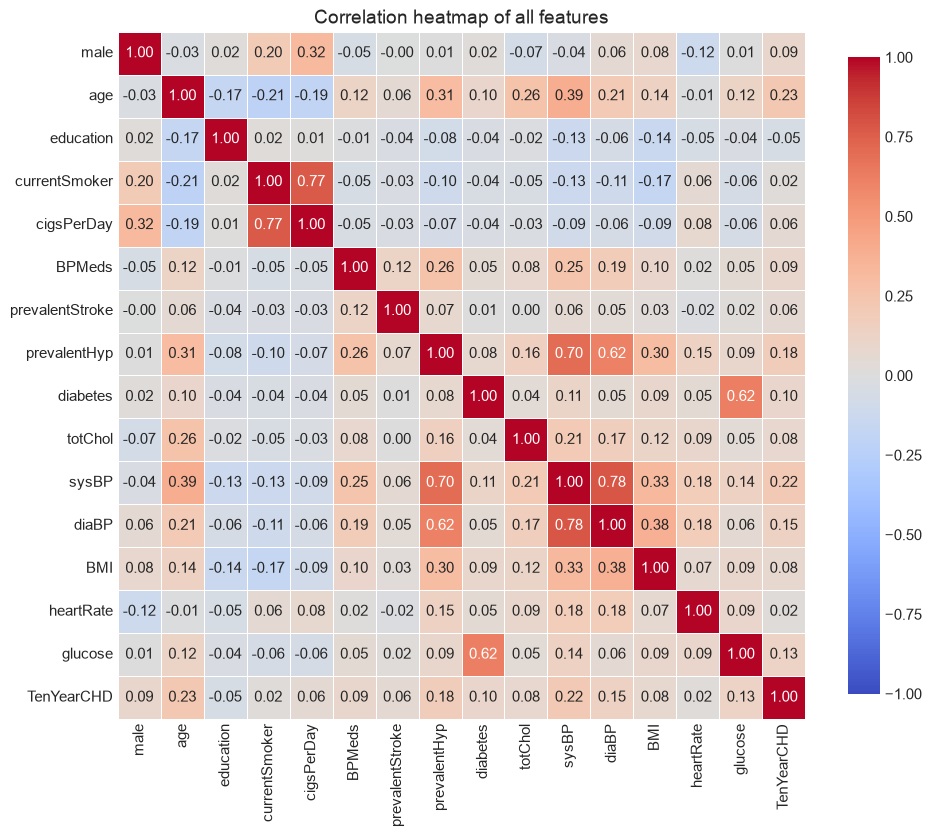

age                0.225
sysBP              0.216
prevalentHyp       0.178
diaBP              0.145
glucose            0.126
diabetes           0.097
male               0.088
BPMeds             0.087
totChol            0.082
BMI                0.075
prevalentStroke    0.062
cigsPerDay         0.058
heartRate          0.023
currentSmoker      0.019
education         -0.054
Name: TenYearCHD, dtype: float64


In [74]:

# --- 1. Compute the correlation matrix (all numeric columns) ---
corr = df.corr(numeric_only=True)

# --- 2. Draw it as a heatmap ---
plt.figure(figsize=(10, 9))
sns.heatmap(corr,
            annot=True,            # print the number inside each cell
            fmt='.2f',             # round those numbers to 2 decimals
            cmap='coolwarm',       # colour scale: blue = negative, red = positive
            center=0,              # a correlation of 0 shows as white
            vmin=-1, vmax=1,       # lock the scale to the full -1..+1 range
            square=True,           # square cells
            linewidths=0.5,        # thin gridlines between cells
            cbar_kws={'shrink': 0.8})   # shrink the colour bar a little
plt.title('Correlation heatmap of all features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# --- 3. Rank each feature by its correlation with the target ---
target_corr = corr['TenYearCHD'].drop('TenYearCHD').sort_values(ascending=False)
print(target_corr.round(3))

In [75]:
# Dataset structural and statistical health check
# print("Shape of dataset:", df.shape)
# print("\nMissing values count:\n", df.isnull().sum())
# df.describe().T

## 5. Data Preprocessing & Feature Engineering & Pipleline Building

To prevent **data leakage**, all scaling and transformation parameters must be fit strictly on the training partition and transformed on test/validation sets.

In [76]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

## 5.1 Making the input features -multivariate and output binary classification(target variable) ready.
#### - Onehot encoding, train test split, imputing according to the data types and scaling(Standarization)

In [77]:
X = df.drop(columns='TenYearCHD') # input feature for the model / dropping the target column from the dataset to get the input features for the model
y = df['TenYearCHD'] # the output, the target values that the model must classify it accurately

# splitting the data 20% and 80%, and keeping the class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y, # makes sure that the rate of true and false is same on both train and test data
    random_state=42,

)

# Confirming the result
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train CHD rate:", round(y_train.mean(), 3))
print("Test CHD rate :", round(y_test.mean(), 3))

# The three groups of columns (from our column-typing step), three kinds of data
continuous  = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']
binary      = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes']
categorical = ['education']

# A mini-pipeline for each group
continuous_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),      # fill gaps with the median
    ('scale',  StandardScaler())                       # then standardise, rescales so each has mean 0 and standard deviation 1 (puts them all on a comparable scale).
])

binary_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent'))  # fill gaps with the mode, most frequent
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),               # fill gaps with the mode
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # turn categories into 0/1 columns
])

# Combine: apply each mini-pipeline to its own columns
preprocessor = ColumnTransformer([
    ('cont', continuous_pipe,  continuous),
    ('bin',  binary_pipe,      binary),
    ('cat',  categorical_pipe, categorical)
])

# fitting the data to the pipline for preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
print("\nShape before:", X_train.shape)
print("Shape after :", X_train_processed.shape)

Train shape: (3390, 15)
Test shape : (848, 15)
Train CHD rate: 0.152
Test CHD rate : 0.152

Shape before: (3390, 15)
Shape after : (3390, 18)


In [78]:
print(np.isnan(X_train_processed).any())

processed_df = pd.DataFrame(X_train_processed, # converting the numpy array to the pandas dataframe for better understanding and visualization
                            columns=preprocessor.get_feature_names_out())
print(processed_df.isnull().sum())
processed_df.head()
processed_df.info()

False
cont__age               0
cont__cigsPerDay        0
cont__totChol           0
cont__sysBP             0
cont__diaBP             0
cont__BMI               0
cont__heartRate         0
cont__glucose           0
bin__male               0
bin__currentSmoker      0
bin__BPMeds             0
bin__prevalentStroke    0
bin__prevalentHyp       0
bin__diabetes           0
cat__education_1.0      0
cat__education_2.0      0
cat__education_3.0      0
cat__education_4.0      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cont__age             3390 non-null   float64
 1   cont__cigsPerDay      3390 non-null   float64
 2   cont__totChol         3390 non-null   float64
 3   cont__sysBP           3390 non-null   float64
 4   cont__diaBP           3390 non-null   float64
 5   cont__BMI             3390 non-null   float64
 6   cont

## 6. Model Training 

In [79]:
# Full pipeline: preprocessing, then the model
model_lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, random_state=42)) # Logistic regression model using sklearn, setting the maximum iteration to 1000 and RS 42
])

# Train on the training set
model_lr.fit(X_train, y_train)

# redict on the held-out test set
y_pred = model_lr.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


# AUC — needs probabilities, not the 0/1 labels
y_proba = model_lr.predict_proba(X_test)[:, 1] # checking the probability of the true
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

Accuracy: 0.843

Confusion matrix:
 [[708  11]
 [122   7]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       719
           1       0.39      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.62      0.52      0.50       848
weighted avg       0.78      0.84      0.79       848

ROC-AUC: 0.695


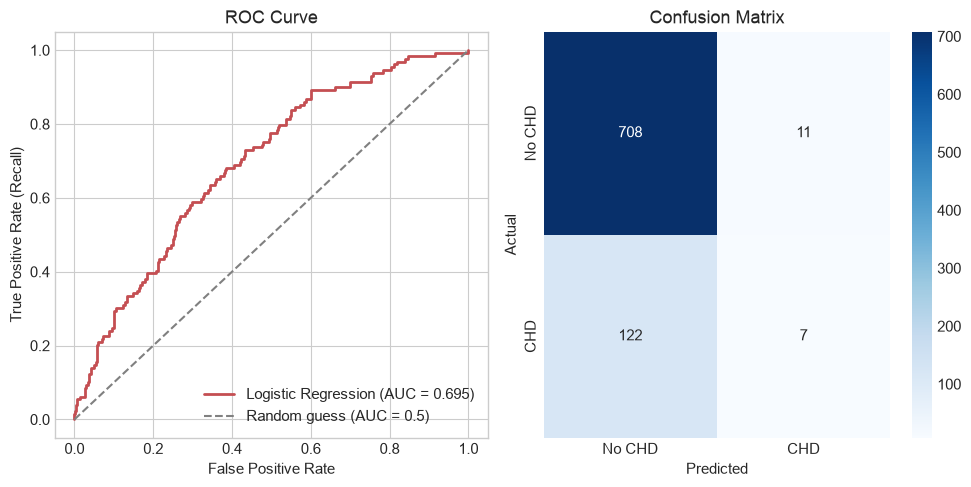

In [80]:
#  y_test, y_pred, and y_proba
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(fpr, tpr, color='#C44E52', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'], ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('roc_and_confusion.png', dpi=150)
plt.show()

## 6.1 Balancing the class imbalance on Logistic Regression

In [81]:
# here balanceing the class of true and false with clas_weight
model_lr_balanced = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')) 
])
model_lr_balanced.fit(X_train, y_train)
y_pred_bal = model_lr_balanced.predict(X_test)

# predictions + probabilities from the balanced model
y_pred_bal  = model_lr_balanced.predict(X_test)
y_proba_bal = model_lr_balanced.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred_bal), 3))

# Confusion matrix
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_bal))

# Precision / recall / F1 per class
print("\nClassification report:")
print(classification_report(y_test, y_pred_bal, digits=3))

# AUC (uses probabilities)
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_bal), 3))

Accuracy: 0.666

Confusion matrix:
[[489 230]
 [ 53  76]]

Classification report:
              precision    recall  f1-score   support

           0      0.902     0.680     0.776       719
           1      0.248     0.589     0.349       129

    accuracy                          0.666       848
   macro avg      0.575     0.635     0.563       848
weighted avg      0.803     0.666     0.711       848

ROC-AUC: 0.696


In [82]:
# evaluation metrics function - for reusability and better understanding of the model performance
def evaluate_model(model, X_test, y_test, name="Model"):
    """Run a fitted model on the test set and return its metrics as a dict."""
    # 1. Predictions (0/1 labels)
    y_pred = model.predict(X_test)

    # 2. A score for AUC: probability if available, otherwise decision_function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # 3. Collect the metrics
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 3),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 3),
        'AUC':       round(roc_auc_score(y_test, y_score), 3),
    }

In [83]:
# comparing the results of the balanced class data and default class data
results = []
results.append(evaluate_model(model_lr,          X_test, y_test, "LogReg (default)"))
results.append(evaluate_model(model_lr_balanced, X_test, y_test, "LogReg (balanced)"))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model  Accuracy  Precision  Recall    F1   AUC
 LogReg (default)     0.843      0.389   0.054 0.095 0.695
LogReg (balanced)     0.666      0.248   0.589 0.349 0.696


## 6.2 Comparing Different Classification Model. Navie Bayes, K-NN, Decision Tree and SVM

In [84]:
# Comparing the results of the balanced class data and default class data with other classifiers
results = []
results.append(evaluate_model(model_lr_balanced, X_test, y_test, "Logistic Regression"))
classifiers = {
    'Naive Bayes':   GaussianNB(),
    'k-NN':          KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'SVM':           SVC(class_weight='balanced', random_state=42),
}

# Build, train, and evaluate each — same preprocessor, same evalutaion function
for name, clf in classifiers.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    results.append(evaluate_model(pipe, X_test, y_test, name))

# The full comparison table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.666      0.248   0.589 0.349 0.696
        Naive Bayes     0.807      0.254   0.140 0.180 0.674
               k-NN     0.842      0.400   0.078 0.130 0.543
      Decision Tree     0.750      0.139   0.124 0.131 0.493
                SVM     0.678      0.235   0.496 0.319 0.667


In [85]:
#SMOTE / adding the syntetic data to balance the class according to the neighbour 
# Plain classifiers — no class_weight, because SMOTE handles the balance for all
results_smote = []
for name, clf in classifiers.items():
    pipe = ImbPipeline([
        ('prep',  preprocessor),          # impute + scale + encode
        ('smote', SMOTE(random_state=42)),# balance the TRAINING data only
        ('clf',   clf)                    # the algorithm
    ])
    pipe.fit(X_train, y_train)
    results_smote.append(evaluate_model(pipe, X_test, y_test, name))

print("Evaluation metrics for the SMOTE model")
print(pd.DataFrame(results_smote).to_string(index=False))

Evaluation metrics for the SMOTE model
        Model  Accuracy  Precision  Recall    F1   AUC
  Naive Bayes     0.764      0.265   0.310 0.286 0.671
         k-NN     0.623      0.191   0.457 0.269 0.564
Decision Tree     0.733      0.220   0.295 0.252 0.553
          SVM     0.703      0.259   0.512 0.344 0.650


## 6.3 Experiement here with Scaling on and off

In [86]:
def make_preprocessor(scale=True):
    steps = [('impute', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scale', StandardScaler()))     # only added when scale=True
    cont_pipe = Pipeline(steps)
    return ColumnTransformer([('cont', cont_pipe, continuous),
                              ('bin', binary_pipe, binary),
                              ('cat', categorical_pipe, categorical)])

def get_classifiers():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'Naive Bayes':         GaussianNB(),
        'k-NN':                KNeighborsClassifier(n_neighbors=5),
        'Decision Tree':       DecisionTreeClassifier(random_state=42),
        'SVM':                 SVC(random_state=42),
    }

# run every algorithm under both conditions
rows = []
for scale_flag in [True, False]:
    prep = make_preprocessor(scale=scale_flag)
    for name, clf in get_classifiers().items():
        pipe = ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=42)), ('clf', clf)]).fit(X_train, y_train)
        r = evaluate_model(pipe, X_test, y_test, name)
        r['Scaling'] = 'ON' if scale_flag else 'OFF'
        rows.append(r)

res = pd.DataFrame(rows)

# --- show scaled vs unscaled side by side for each metric ---
for metric in ['Recall', 'F1', 'AUC']:
    p = res.pivot(index='Model', columns='Scaling', values=metric)[['ON', 'OFF']]
    p['change'] = (p['ON'] - p['OFF']).round(3)
    print(f"\n=== {metric} : scaling ON vs OFF ===")
    print(p.to_string())


=== Recall : scaling ON vs OFF ===
Scaling                 ON    OFF  change
Model                                    
Decision Tree        0.295  0.233   0.062
Logistic Regression  0.605  0.605   0.000
Naive Bayes          0.310  0.295   0.015
SVM                  0.512  0.636  -0.124
k-NN                 0.457  0.512  -0.055

=== F1 : scaling ON vs OFF ===
Scaling                 ON    OFF  change
Model                                    
Decision Tree        0.252  0.224   0.028
Logistic Regression  0.347  0.355  -0.008
Naive Bayes          0.286  0.279   0.007
SVM                  0.344  0.342   0.002
k-NN                 0.269  0.308  -0.039

=== AUC : scaling ON vs OFF ===
Scaling                 ON    OFF  change
Model                                    
Decision Tree        0.553  0.540   0.013
Logistic Regression  0.693  0.693   0.000
Naive Bayes          0.671  0.669   0.002
SVM                  0.650  0.685  -0.035
k-NN                 0.564  0.593  -0.029


## 6.4 Cross - Validatating the model

In [87]:
# 5 -fold cross validation, to check if the scaling result is not just random
# --- 5-fold stratified cross-validation, scaling ON vs OFF ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'recall', 'f1']

rows = []
for scale_flag in [True, False]:
    prep = make_preprocessor(scale=scale_flag)
    for name, clf in get_classifiers().items():
        pipe = ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=42)), ('clf', clf)])
        cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
        rows.append({'Model': name,
                     'Scaling': 'ON' if scale_flag else 'OFF',
                     'AUC_mean': round(cvres['test_roc_auc'].mean(), 3),
                     'AUC_std':  round(cvres['test_roc_auc'].std(), 3),
                     'Recall_mean': round(cvres['test_recall'].mean(), 3),
                     'F1_mean':     round(cvres['test_f1'].mean(), 3)})

res = pd.DataFrame(rows)

# full table
print("=== 5-fold CV results ===")
print(res.to_string(index=False))

# AUC scaled vs unscaled, with the fold-to-fold wobble (std) for comparison
print("\n=== AUC: scaling ON vs OFF (is the change bigger than the noise?) ===")
piv = res.pivot(index='Model', columns='Scaling', values='AUC_mean')[['ON','OFF']]
piv['change'] = (piv['ON'] - piv['OFF']).round(3)
piv['typical_std'] = res.groupby('Model')['AUC_std'].mean().round(3)
print(piv.to_string())

=== 5-fold CV results ===
              Model Scaling  AUC_mean  AUC_std  Recall_mean  F1_mean
Logistic Regression      ON     0.725    0.028        0.670    0.384
        Naive Bayes      ON     0.694    0.037        0.392    0.347
               k-NN      ON     0.632    0.020        0.559    0.330
      Decision Tree      ON     0.557    0.020        0.307    0.257
                SVM      ON     0.659    0.024        0.485    0.325
Logistic Regression     OFF     0.727    0.028        0.670    0.385
        Naive Bayes     OFF     0.707    0.027        0.365    0.342
               k-NN     OFF     0.608    0.025        0.495    0.295
      Decision Tree     OFF     0.552    0.018        0.266    0.245
                SVM     OFF     0.726    0.028        0.695    0.377

=== AUC: scaling ON vs OFF (is the change bigger than the noise?) ===
Scaling                 ON    OFF  change  typical_std
Model                                                 
Decision Tree        0.557  0.552 

## 6.5 Ensemble Algorithm. Random Forest & Gradient Boosting

In [88]:
# running the ensemble alrorithms
ensemble_clfs = {
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}
ens_rows = []
for name, clf in ensemble_clfs.items():
    pipe = ImbPipeline([('prep', make_preprocessor(scale=True)),
                        ('smote', SMOTE(random_state=42)),
                        ('clf', clf)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=['roc_auc','recall','f1'])
    ens_rows.append({'Model': name,
                     'AUC_mean':    round(cvres['test_roc_auc'].mean(), 3),
                     'AUC_std':     round(cvres['test_roc_auc'].std(), 3),
                     'Recall_mean': round(cvres['test_recall'].mean(), 3),
                     'F1_mean':     round(cvres['test_f1'].mean(), 3)})
ens_df = pd.DataFrame(ens_rows)
print(ens_df.to_string(index=False))

            Model  AUC_mean  AUC_std  Recall_mean  F1_mean
    Random Forest     0.683    0.011        0.198    0.248
Gradient Boosting     0.700    0.023        0.351    0.337


In [89]:
# combine your 5 classical models + the 2 ensembles into one comparison
all_models = get_classifiers()
all_models['Random Forest']     = RandomForestClassifier(random_state=42)
all_models['Gradient Boosting'] = GradientBoostingClassifier(random_state=42)

prep = make_preprocessor(scale=True)         # same standard pipeline for everyone
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

master_rows = []
for name, clf in all_models.items():
    pipe = ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=42)), ('clf', clf)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    master_rows.append({'Model': name,
                        'Accuracy':  round(cvres['test_accuracy'].mean(), 3),
                        'Precision': round(cvres['test_precision'].mean(), 3),
                        'Recall':    round(cvres['test_recall'].mean(), 3),
                        'F1':        round(cvres['test_f1'].mean(), 3),
                        'AUC':       round(cvres['test_roc_auc'].mean(), 3)})

master_df = pd.DataFrame(master_rows).sort_values('AUC', ascending=False).reset_index(drop=True)
print(master_df.to_string(index=False))

              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.673      0.269   0.670 0.384 0.725
  Gradient Boosting     0.790      0.324   0.351 0.337 0.700
        Naive Bayes     0.776      0.312   0.392 0.347 0.694
      Random Forest     0.818      0.336   0.198 0.248 0.683
                SVM     0.693      0.245   0.485 0.325 0.659
               k-NN     0.655      0.234   0.559 0.330 0.632
      Decision Tree     0.731      0.221   0.307 0.257 0.557


## 6.6 Logistic Regression - the best performer. On test data

In [90]:
final_model = ImbPipeline([('prep', make_preprocessor(scale=True)),
                           ('smote', SMOTE(random_state=42)),
                           ('clf', LogisticRegression(max_iter=2000, random_state=42))])
final_model.fit(X_train, y_train)

# Predict on the untouched test set
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

# Final metrics
print("FINAL TEST-SET RESULTS — Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1       :", round(f1_score(y_test, y_pred), 3))
print("AUC      :", round(roc_auc_score(y_test, y_proba), 3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

FINAL TEST-SET RESULTS — Logistic Regression
Accuracy : 0.654
Precision: 0.244
Recall   : 0.605
F1       : 0.347
AUC      : 0.693

Confusion matrix:
 [[477 242]
 [ 51  78]]

Classification report:
               precision    recall  f1-score   support

           0      0.903     0.663     0.765       719
           1      0.244     0.605     0.347       129

    accuracy                          0.654       848
   macro avg      0.574     0.634     0.556       848
weighted avg      0.803     0.654     0.702       848



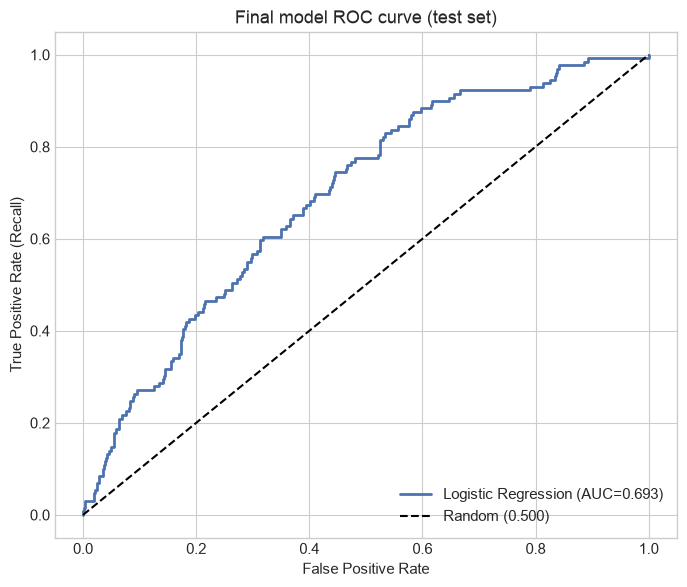

In [114]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'Logistic Regression (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (0.500)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Recall)')
plt.title('Final model ROC curve (test set)'); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('C1_final_roc.png', dpi=150); plt.savefig('C1_final_roc.pdf'); plt.show()

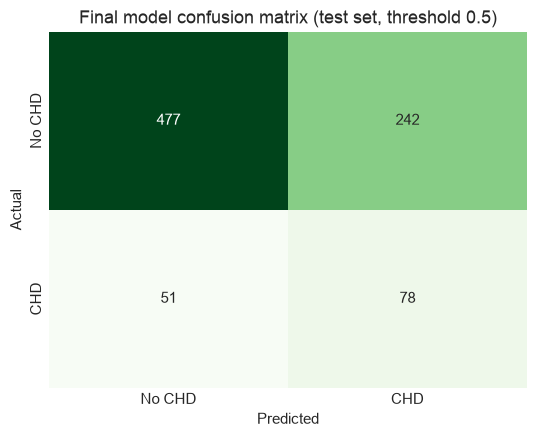

In [116]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Final model confusion matrix (test set, threshold 0.5)')
plt.tight_layout(); plt.savefig('C3_final_confusion.png', dpi=150); plt.savefig('C3_final_confusion.pdf'); plt.show()

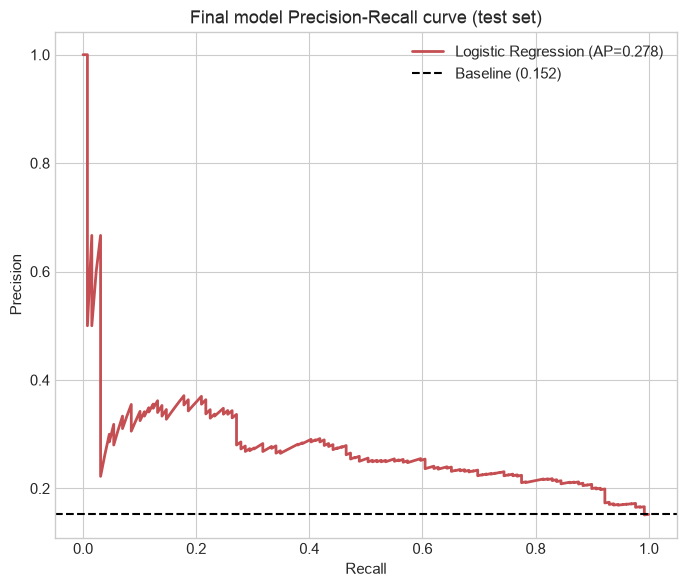

In [115]:
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color='#C44E52', lw=2, label=f'Logistic Regression (AP={average_precision_score(y_test, y_proba):.3f})')
plt.axhline(y_test.mean(), ls='--', color='k', label=f'Baseline ({y_test.mean():.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Final model Precision-Recall curve (test set)'); plt.legend(loc='upper right')
plt.tight_layout(); plt.savefig('C2_final_pr.png', dpi=150); plt.savefig('C2_final_pr.pdf'); plt.show()


# 7. Model Evaluation and Interpretation

In [ ]:
# setting all the model names with their respective class from the SKlearn class
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'Naive Bayes':         GaussianNB(),
        'k-NN':                KNeighborsClassifier(n_neighbors=5),
        'Decision Tree':       DecisionTreeClassifier(random_state=42),
        'SVM':                 SVC(probability=True, random_state=42),
        'Random Forest':       RandomForestClassifier(random_state=42),
        'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    }


def fit_and_evaluate_on_test(scale=True):
    proba, pred, metrics = {}, {}, []
    for name, clf in get_models().items():
        pipe = ImbPipeline([('prep', make_preprocessor(scale=scale)),
                            ('smote', SMOTE(random_state=42)),
                            ('clf', clf)])
        pipe.fit(X_train, y_train)                       # train on training set
        p = pipe.predict_proba(X_test)[:, 1]             # probabilities on the TEST set
        yhat = (p >= 0.5).astype(int)                    # labels at threshold 0.5
        proba[name] = p; pred[name] = yhat
        metrics.append({'Model': name,
                        'Accuracy':  round(accuracy_score(y_test, yhat), 3),
                        'Precision': round(precision_score(y_test, yhat, zero_division=0), 3),
                        'Recall':    round(recall_score(y_test, yhat, zero_division=0), 3),
                        'F1':        round(f1_score(y_test, yhat, zero_division=0), 3),
                        'AUC':       round(roc_auc_score(y_test, p), 3)})
    metrics_df = pd.DataFrame(metrics).sort_values('AUC', ascending=False).reset_index(drop=True)
    return proba, pred, metrics_df

#  Plot functions 
def plot_model_bars(metrics_df, title, fname):
    d = metrics_df.set_index('Model')[['AUC', 'F1', 'Recall']]
    ax = d.plot(kind='barh', figsize=(10, 6), width=0.75, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.invert_yaxis(); ax.set_xlabel('Score (test set)'); ax.set_title(title); ax.legend(loc='lower right')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.savefig(fname.replace('.png','.pdf')); plt.show()

def plot_roc(proba, title, fname):
    plt.figure(figsize=(8, 7))
    for name, p in proba.items():
        fpr, tpr, _ = roc_curve(y_test, p)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random (0.500)')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Recall)')
    plt.title(title); plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.savefig(fname.replace('.png','.pdf')); plt.show()

def plot_pr(proba, title, fname):
    plt.figure(figsize=(8, 7))
    for name, p in proba.items():
        prec, rec, _ = precision_recall_curve(y_test, p)
        plt.plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test, p):.3f})')
    plt.axhline(y_test.mean(), ls='--', color='k', label=f'Baseline ({y_test.mean():.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

def plot_confusion_grid(pred, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7)); axes = axes.ravel()
    for i, (name, yhat) in enumerate(pred.items()):
        sns.heatmap(confusion_matrix(y_test, yhat), annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    xticklabels=['No CHD','CHD'], yticklabels=['No CHD','CHD'])
        axes[i].set_title(name); axes[i].set_xlabel('Pred'); axes[i].set_ylabel('Actual')
    axes[7].axis('off')
    plt.suptitle(title, fontsize=13); plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(fname, dpi=130); plt.savefig(fname.replace('.png','.pdf')); plt.show()


In [112]:
# running scaled vs not scalled
proba_s, pred_s, metrics_s = fit_and_evaluate_on_test(scale=True)
proba_u, pred_u, metrics_u = fit_and_evaluate_on_test(scale=False)

In [93]:
print("=== TEST-SET METRICS (scaled) ===");   print(metrics_s.to_string(index=False))
print("\n=== TEST-SET METRICS (unscaled) ==="); print(metrics_u.to_string(index=False))

=== TEST-SET METRICS (scaled) ===
              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.654      0.244   0.605 0.347 0.693
        Naive Bayes     0.764      0.265   0.310 0.286 0.671
      Random Forest     0.809      0.268   0.147 0.190 0.652
                SVM     0.709      0.254   0.473 0.331 0.650
  Gradient Boosting     0.776      0.264   0.264 0.264 0.650
               k-NN     0.623      0.191   0.457 0.269 0.564
      Decision Tree     0.733      0.220   0.295 0.252 0.553

=== TEST-SET METRICS (unscaled) ===
              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.666      0.252   0.605 0.355 0.693
                SVM     0.631      0.233   0.620 0.338 0.685
        Naive Bayes     0.769      0.266   0.295 0.279 0.669
  Gradient Boosting     0.823      0.328   0.155 0.211 0.666
      Random Forest     0.821      0.205   0.062 0.095 0.647
               k-NN     0.650      0.220   0.512 0.308 0.593
      Decision

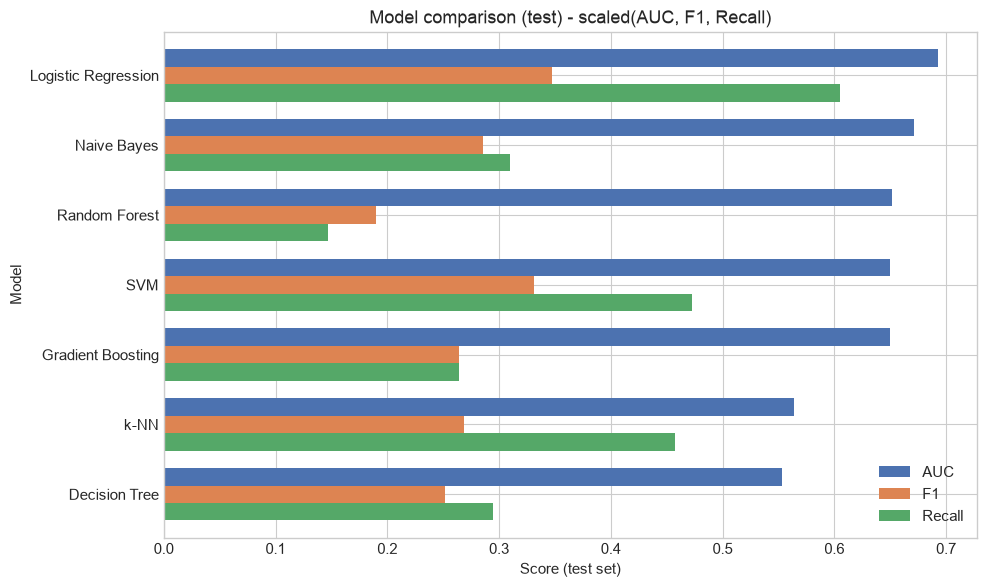

In [94]:
plot_model_bars(metrics_s, 'Model comparison (test) - scaled(AUC, F1, Recall)',   'A1_bars_scaled.png')

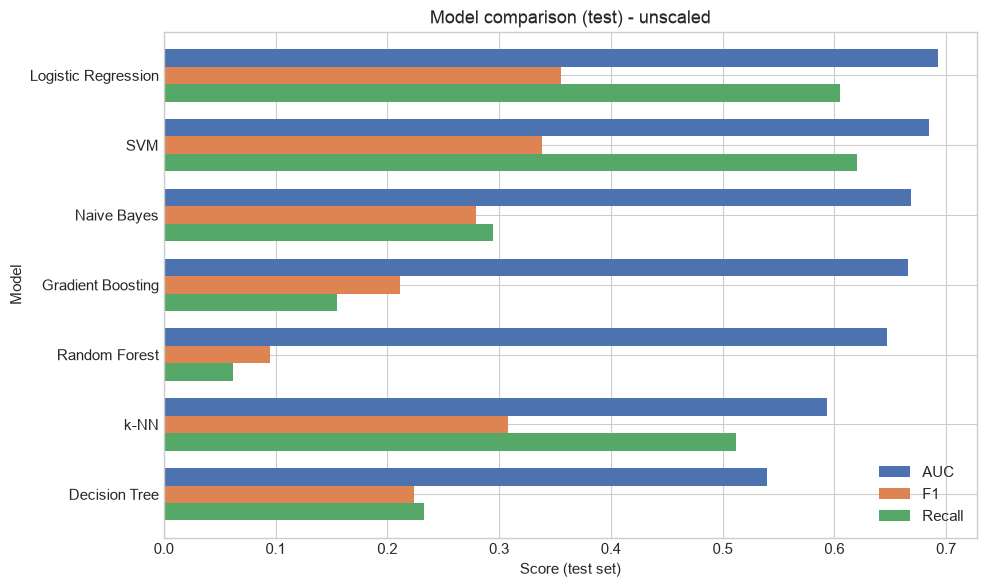

In [95]:
plot_model_bars(metrics_u, 'Model comparison (test) - unscaled', 'A1_bars_unscaled.png')

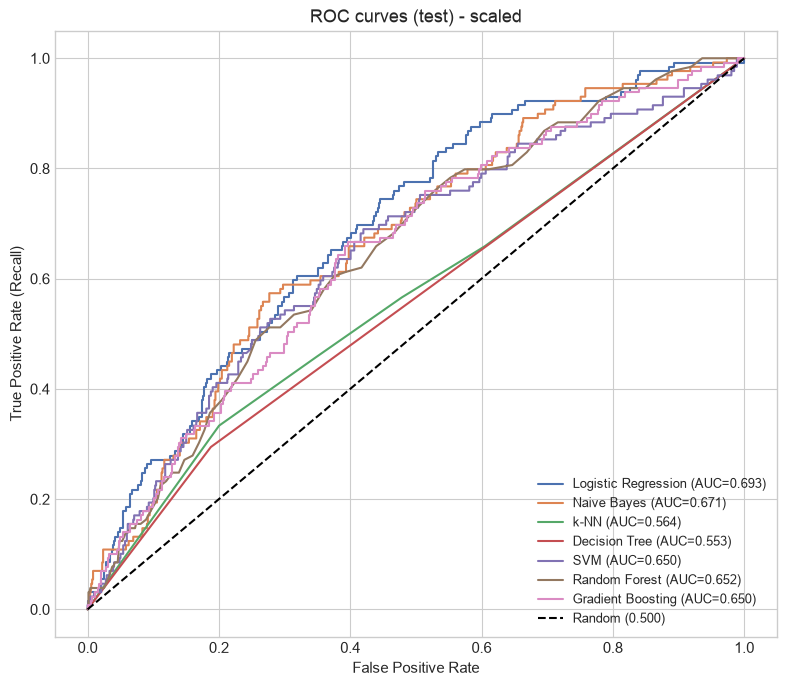

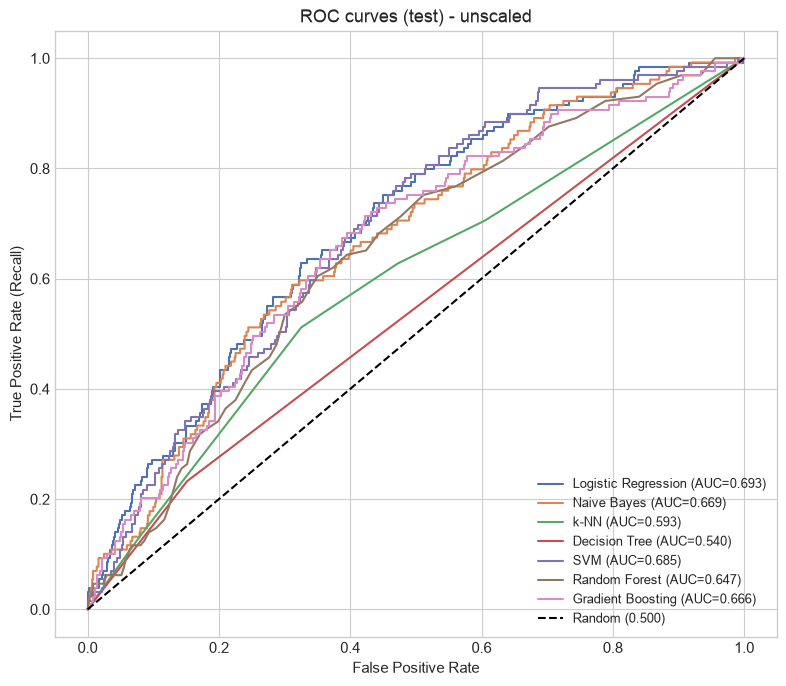

In [102]:
plot_roc(proba_s, 'ROC curves (test) - scaled',   'A2_roc_scaled.png')
plot_roc(proba_u, 'ROC curves (test) - unscaled', 'A2_roc_unscaled.png')

In [99]:
print(type(auc))

<class 'function'>


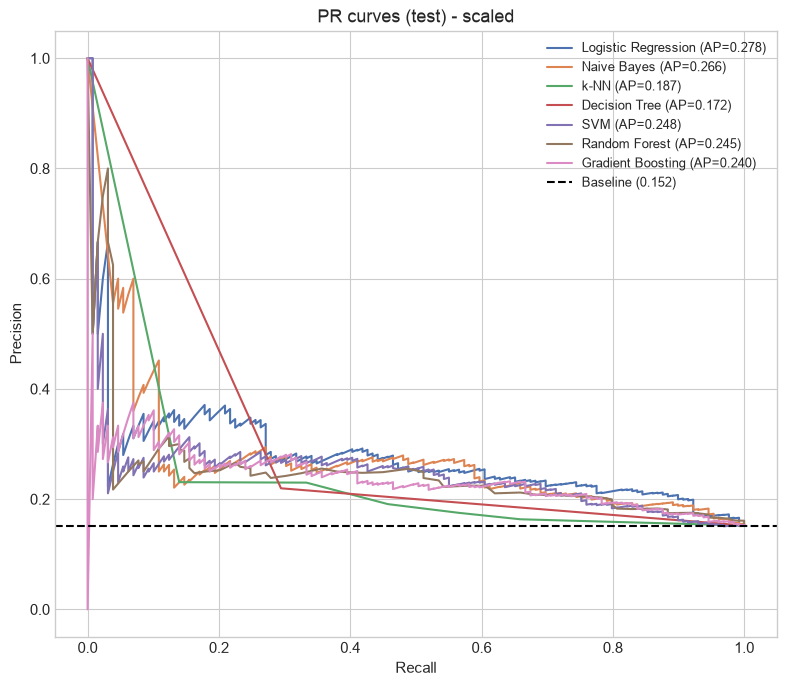

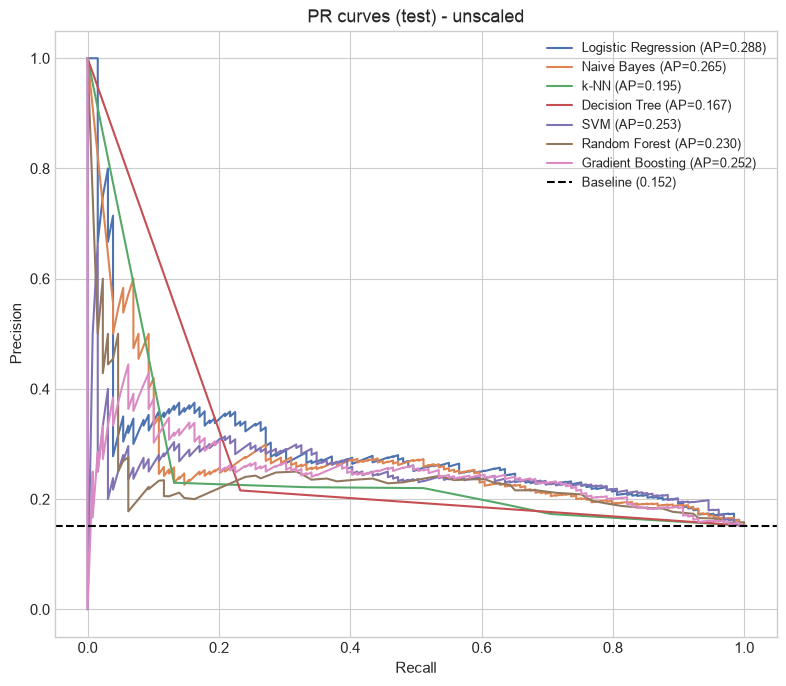

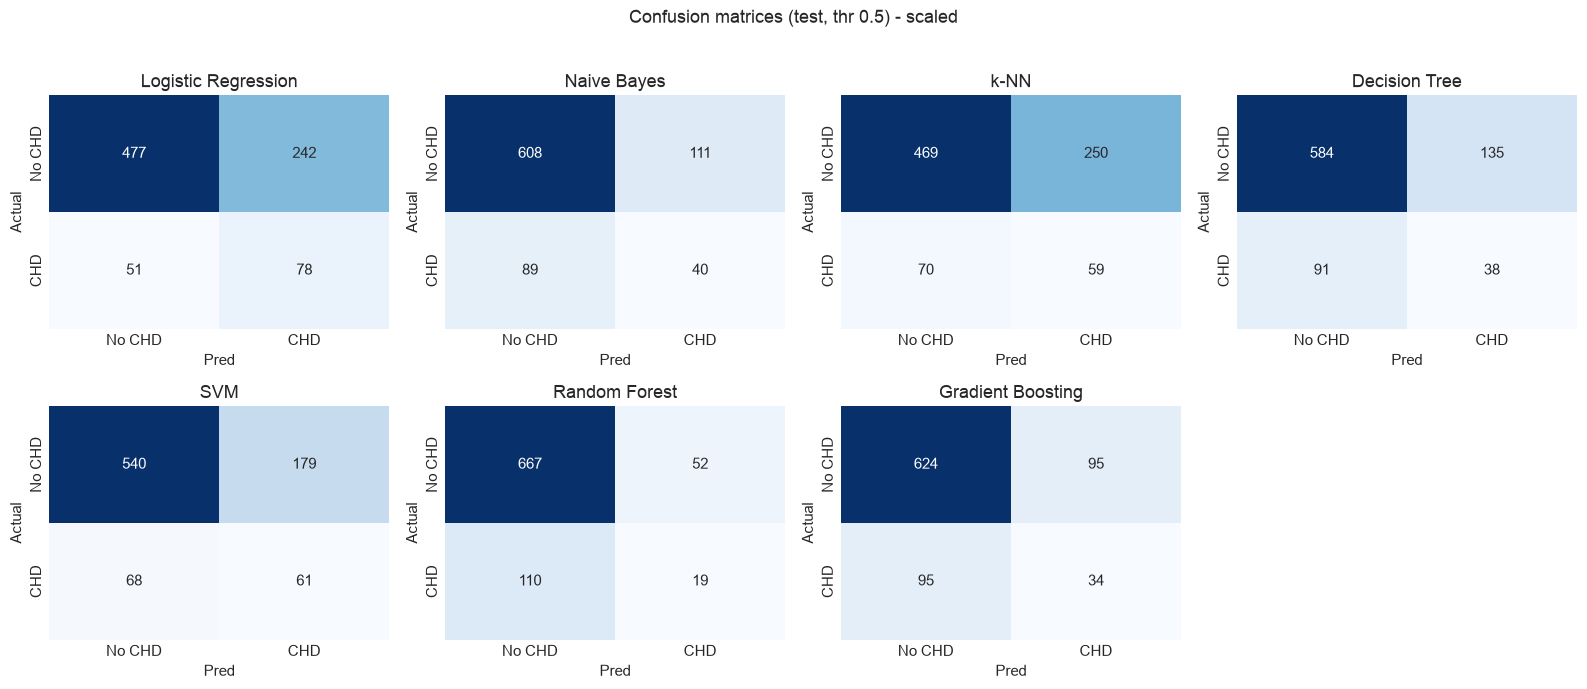

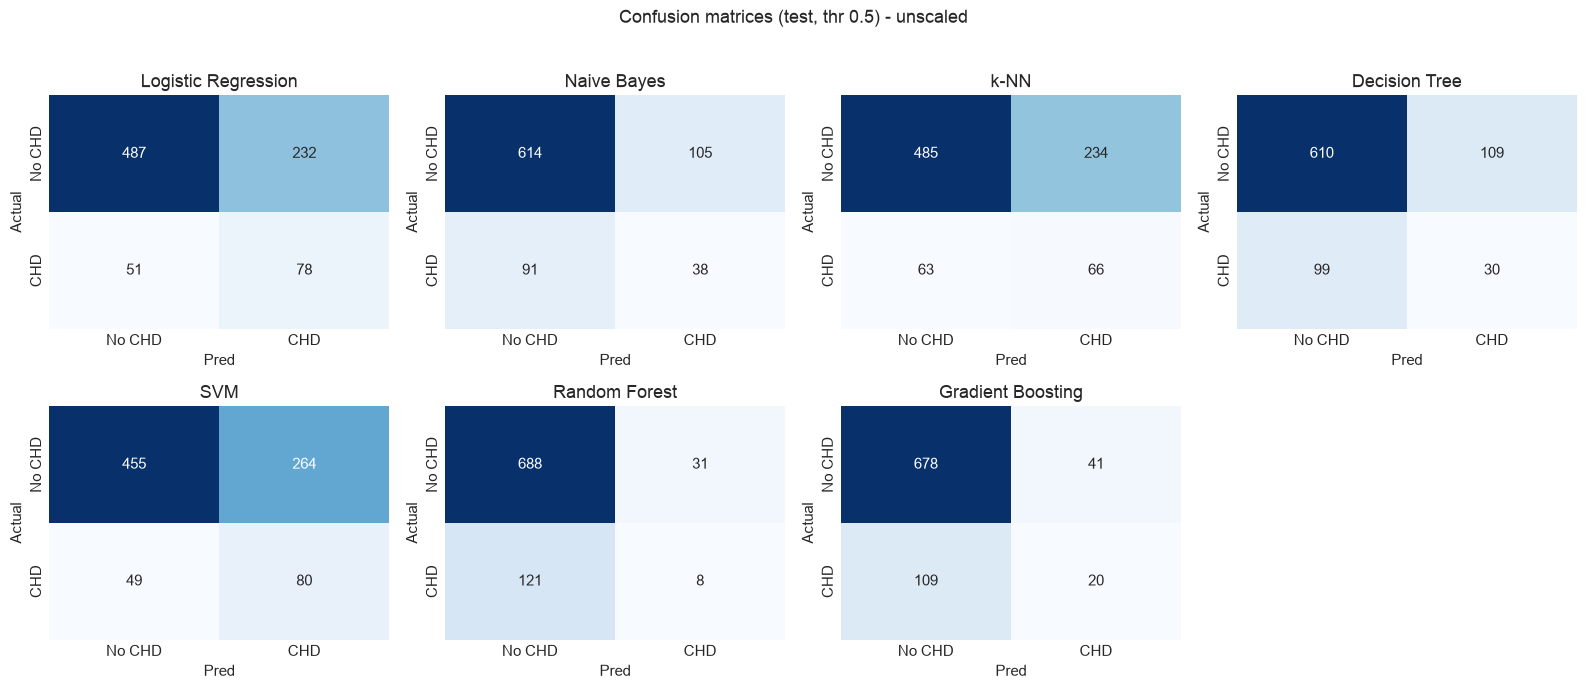

In [ ]:

plot_pr(proba_s, 'PR curves (test) - scaled',   'A3_pr_scaled.png')
plot_pr(proba_u, 'PR curves (test) - unscaled', 'A3_pr_unscaled.png')
plot_confusion_grid(pred_s, 'Confusion matrices (test, thr 0.5) - scaled',   'A4_confusion_scaled.png')
plot_confusion_grid(pred_u, 'Confusion matrices (test, thr 0.5) - unscaled', 'A4_confusion_unscaled.png')

In [106]:
#For each model: 5-fold CV AUC (mean + std), scaling ON and OFF 
def scaling_cv_results():
    rows = []
    for scale_flag in [True, False]:
        prep = make_preprocessor(scale=scale_flag)
        for name, clf in get_models().items():
            pipe = ImbPipeline([('prep', prep), ('smote', SMOTE(random_state=42)), ('clf', clf)])
            scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')  # 5 fold AUCs
            rows.append({'Model': name, 'Scaling': 'ON' if scale_flag else 'OFF',
                         'AUC_mean': scores.mean(), 'AUC_std': scores.std()})
    return pd.DataFrame(rows)

# Grouped bar chart: ON vs OFF per model, error bars = fold std 
def plot_scaling_bars(res, fname):
    on  = res[res.Scaling == 'ON'].set_index('Model')
    off = res[res.Scaling == 'OFF'].set_index('Model')
    models = on.index.tolist()
    x = np.arange(len(models)); width = 0.38
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, on['AUC_mean'],  width, yerr=on['AUC_std'],  capsize=4, label='Scaling ON',  color='#4C72B0')
    ax.bar(x + width/2, off['AUC_mean'], width, yerr=off['AUC_std'], capsize=4, label='Scaling OFF', color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_ylabel('AUC (5-fold CV mean)'); ax.set_ylim(0.5, 0.8)
    ax.set_title('Effect of feature scaling on AUC (error bars = fold-to-fold std)')
    ax.legend()
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.savefig(fname.replace('.png','.pdf')); plt.show()

In [110]:
res = scaling_cv_results()
print(res.round(3).to_string(index=False))

# summary: is the change bigger than the noise?
piv = res.pivot(index='Model', columns='Scaling', values='AUC_mean')[['ON','OFF']]
piv['change']   = piv['ON'] - piv['OFF']
piv['fold_std'] = res.groupby('Model')['AUC_std'].mean()
print("\nChange vs noise:")
print(piv.round(3).to_string())

              Model Scaling  AUC_mean  AUC_std
Logistic Regression      ON     0.725    0.028
        Naive Bayes      ON     0.694    0.037
               k-NN      ON     0.632    0.020
      Decision Tree      ON     0.557    0.020
                SVM      ON     0.659    0.024
      Random Forest      ON     0.683    0.011
  Gradient Boosting      ON     0.700    0.023
Logistic Regression     OFF     0.727    0.028
        Naive Bayes     OFF     0.707    0.027
               k-NN     OFF     0.608    0.025
      Decision Tree     OFF     0.552    0.018
                SVM     OFF     0.726    0.028
      Random Forest     OFF     0.687    0.013
  Gradient Boosting     OFF     0.706    0.029

Change vs noise:
Scaling                 ON    OFF  change  fold_std
Model                                              
Decision Tree        0.557  0.552   0.005     0.019
Gradient Boosting    0.700  0.706  -0.006     0.026
Logistic Regression  0.725  0.727  -0.002     0.028
Naive Bayes      

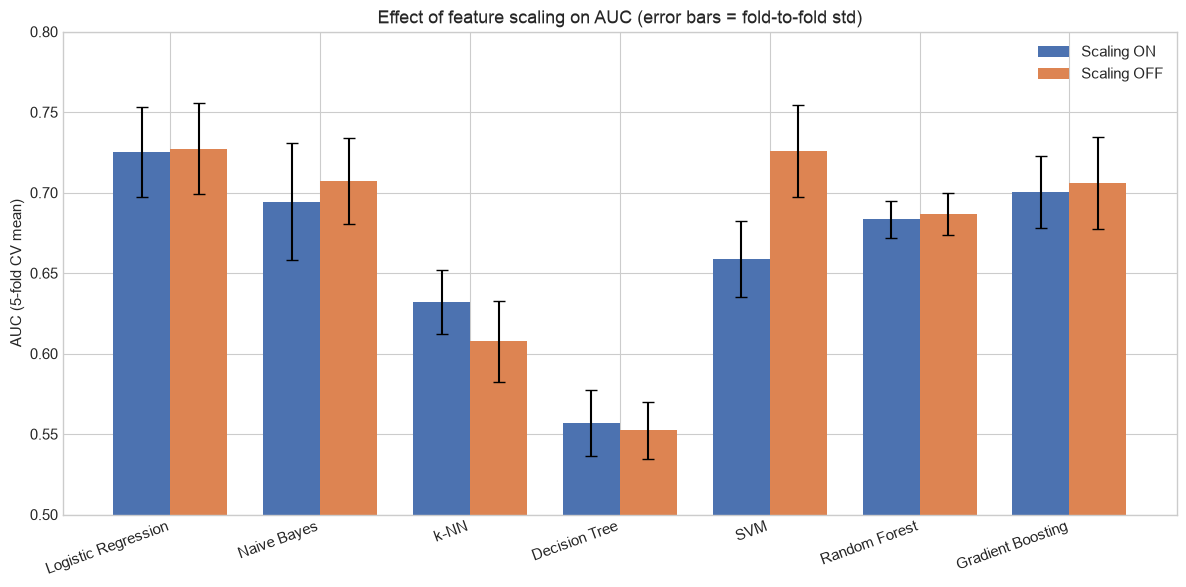

In [111]:
plot_scaling_bars(res, 'B1_scaling_experiment.png')